In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [28]:
df = pd.read_csv(r"C:\Users\shafaat hussain\Desktop\aiml\mushroom\mushrooms.csv")
print(df.shape)
print("Class Balance:\n", df['class'].value_counts(normalize=True))

(8124, 23)
Class Balance:
 class
e    0.517971
p    0.482029
Name: proportion, dtype: float64


In [29]:
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

In [30]:
print("Standard missing (NaN):")
print(df.isnull().sum())

print("\n'?' counts per column:")
question_mark_counts = (df == '?').sum()
print(question_mark_counts[question_mark_counts > 0])  # Show only columns with '?'

Standard missing (NaN):
class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

'?' counts per column:
stalk-root    2480
dtype: int64


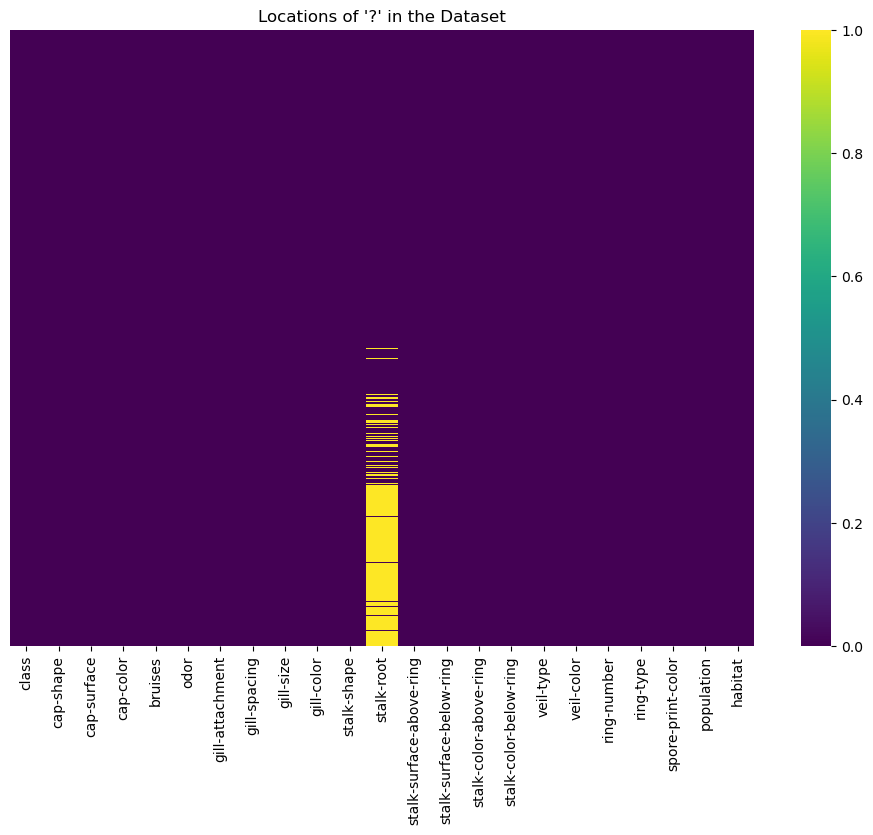

In [32]:
missing_mask = df == '?'
plt.figure(figsize=(12, 8))
sns.heatmap(missing_mask, yticklabels=False, cbar=True, cmap='viridis')
plt.title("Locations of '?' in the Dataset")
plt.show()

In [33]:
df['stalk-root'] = df['stalk-root'].replace('?', np.nan)
imputer = SimpleImputer(strategy='most_frequent')
df['stalk-root'] = imputer.fit_transform(df[['stalk-root']]).ravel()

In [34]:
# Drop useless column
df.drop('veil-type', axis=1, inplace=True)

# Encode target: e=0, p=1 (for binary classification)
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])  # 0=e, 1=p

# Separate features & target
X = df.drop('class', axis=1)
y = df['class']

# One-Hot Encode all categorical features
categorical_features = X.columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)]
)

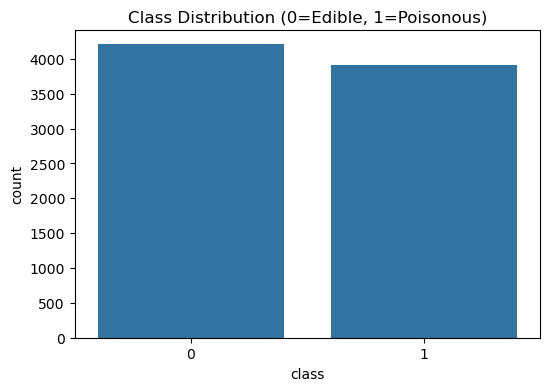

In [35]:
# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df)
plt.title('Class Distribution (0=Edible, 1=Poisonous)')
plt.show()

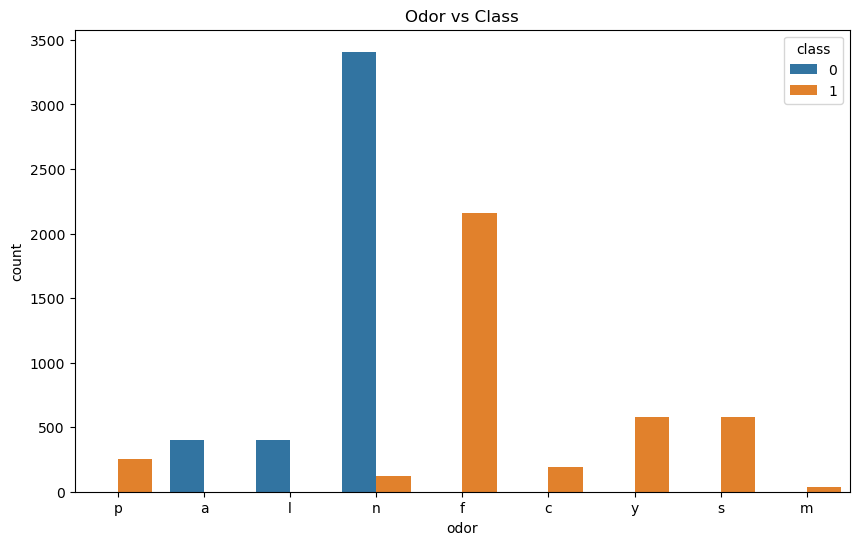

In [36]:
# Example: Feature vs Class
plt.figure(figsize=(10,6))
sns.countplot(x='odor', hue='class', data=df)
plt.title('Odor vs Class')
plt.show()

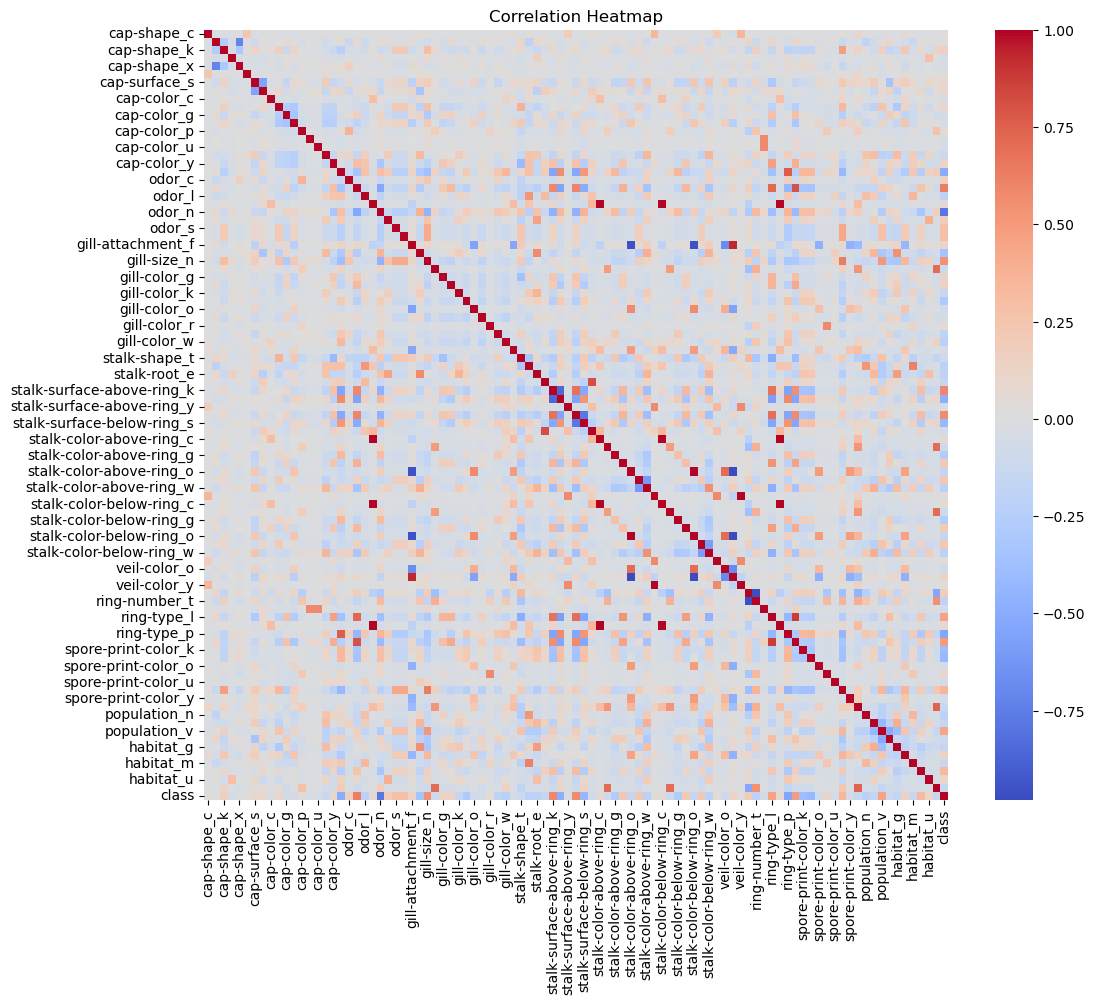

In [37]:
# Correlation heatmap
X_encoded = pd.get_dummies(X, drop_first=True)
corr = pd.concat([X_encoded, y], axis=1).corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


Logistic Regression Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



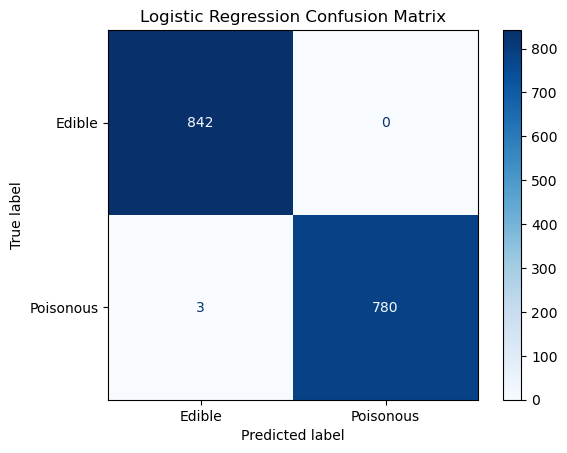


Decision Tree Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



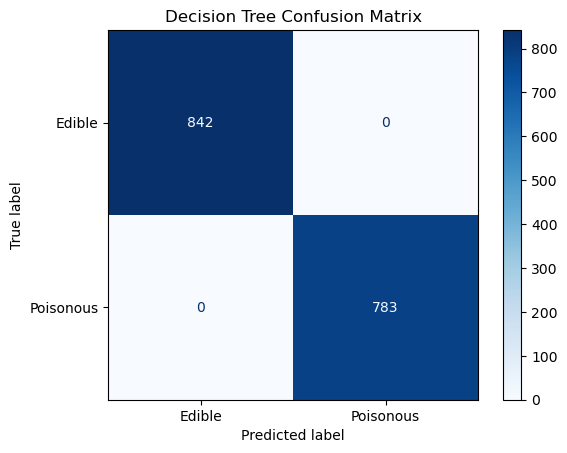


Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



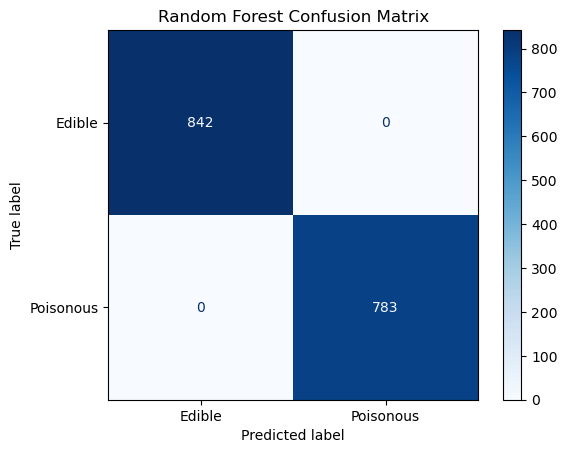

In [39]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results[name] = {'Accuracy': acc, 'F1-Score': f1}
    
    print(f"\n{name} Report:\n", classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Edible', 'Poisonous'])
    disp.plot(cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

In [40]:
results_df = pd.DataFrame(results).T
print("Model Comparison:\n", results_df)

Model Comparison:
                      Accuracy  F1-Score
Logistic Regression  0.998154  0.998081
Decision Tree        1.000000  1.000000
Random Forest        1.000000  1.000000


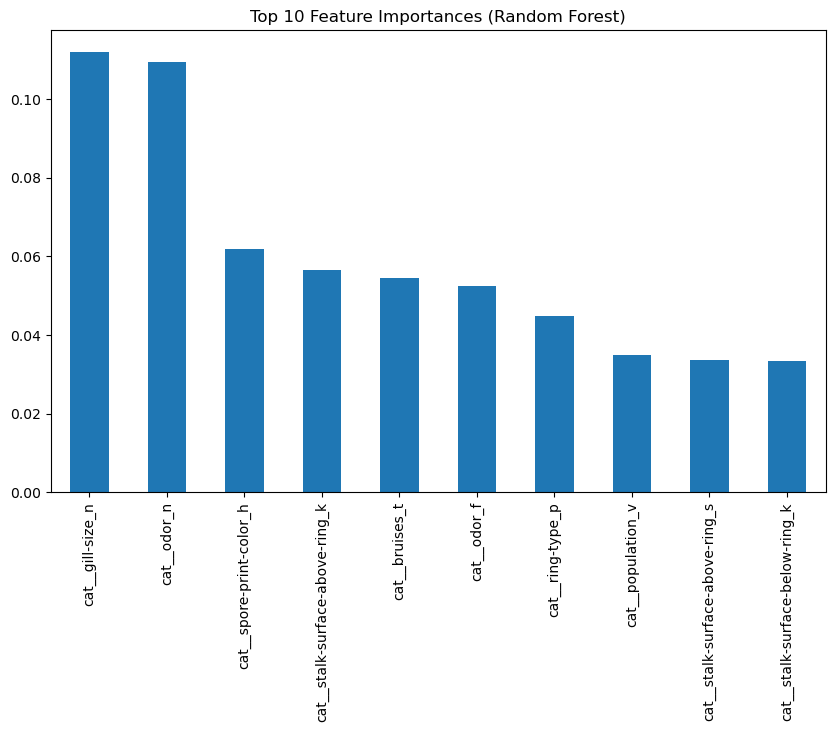

In [41]:
best_model = Pipeline(steps=[('preprocessor', preprocessor), 
                             ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])
best_model.fit(X_train, y_train)

feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

importances = best_model.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.show()